# 🔗 **Merge**

> ### 📌 **TL;DR**
>
> This Jupyter notebook has been created to compare different features with several open source Python libraries for rasters management.
>
> This notebook compares raster merging (mosaicking) strategies across several libraries.
>
> The following libraries will be considered :
>- `rasterio`
>- `rioxarray`
>- `odc-geo`
>- `geoutils`
>- `xarray-spatial`

In [27]:
import numpy as np

import rasterio
from rasterio.merge import merge
from rasterio.plot import show

import rioxarray as rxr
from rioxarray.merge import merge_arrays

import geoutils as gu
from geoutils.raster import merge_rasters

from xrspatial.reproject import merge as xrs_merge

import matplotlib.pyplot as plt

import seaborn as sns #cmap mako

## **Merge**

Merge feature is implemented in `rasterio`, `rioxarray`, `geoutils` and `xarray-spatial` libraries, but not in `odc-geo`.

Merging is the process of combining multiple rasters into a single, continuous image. It can be useful to work on a uniform image for analysis, but also simplifies processing, visualization, storage etc.

In this notebook, we will show how to merge into one image the island of Sardinia that has been separated in two different rasters.

In [2]:
#path to the raster objects
rast1_path = "../data/rasters/sard1.tif"
rast2_path = "../data/rasters/sard2.tif"

### • *rasterio*

With `rasterio`, we will use the [`.merge()`](https://rasterio.readthedocs.io/en/stable/api/rasterio.merge.html) function:

As an argument to this function, we will pass the two opened dataset objects that we want to merge, so we will store them in a variable called `rasters_to_mosaic`:

In [3]:
rasters = [rast1_path, rast2_path]

rasters_to_mosaic = [rasterio.open(r) for r in rasters]

Here is the first raster (North of Sardinia):

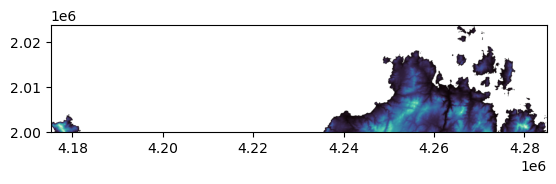

<Axes: >

In [4]:
show(rasters_to_mosaic[1], cmap="mako")

And the second one (rest of the Sardinia island):

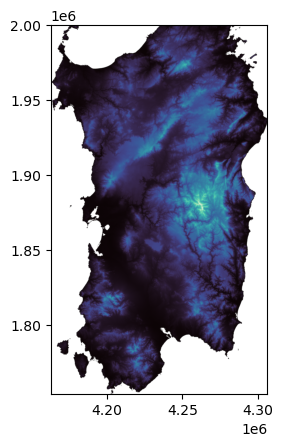

<Axes: >

In [5]:
show(rasters_to_mosaic[0], cmap="mako")

We will then use the `merge` function. We will pass the list of our two opened rasters, and the nodata value we want to assign to our merged raster (`np.nan` in our case).

To be correctly merged, the input rasters must have the same number of bands, data type and CRS.

In [6]:
rasterio_merged = merge(rasters_to_mosaic, nodata=np.nan)

The returned object is a tuple with two elements: a `numpy` array containing values of the input rasters, and the corresponding affine transformation matrix.

In [7]:
rasterio_merged

(array([[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]],
       shape=(1, 5393, 2881), dtype=float32),
 Affine(50.0, 0.0, 4162400.0,
        0.0, -50.0, 2023750.0))

We can finally plot the map, and confirm that the two different parts of Sardinia have been well merged:

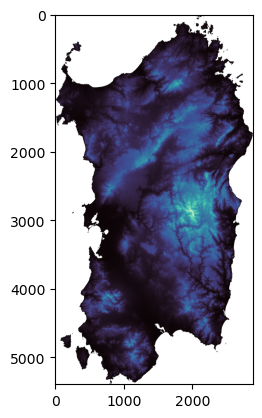

<Axes: >

In [8]:
show(rasterio_merged[0], cmap="mako")

### • *rioxarray*

Once again with `rioxarray`, we will create a mosaic with our two rasters to be merged:

In [ ]:
rasters = [rast1_path, rast2_path]

rasters_to_mosaic = [rxr.open_rasterio(r, chunks="auto") for r in rasters]

In [10]:
rasters_to_mosaic[0]

<xarray.DataArray (band: 1, y: 4918, x: 2881)> Size: 57MB
dask.array<open_rasterio-cd83b0c78dfa08afa5a0a523003f554b<this-array>, shape=(1, 4918, 2881), dtype=float32, chunksize=(1, 4918, 2881), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 23kB 4.162e+06 4.162e+06 ... 4.306e+06 4.306e+06
  * y            (y) float64 39kB 2e+06 2e+06 2e+06 ... 1.754e+06 1.754e+06
    spatial_ref  int64 8B 0
Attributes:
    DataType:                  Generic
    AREA_OR_POINT:             Area
    RepresentationType:        ATHEMATIC
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        1578.8498535156
    STATISTICS_MEAN:           345.44952592539
    STATISTICS_MINIMUM:        -4.1803932189941
    STATISTICS_STDDEV:         298.9554336099
    STATISTICS_VALID_PERCENT:  64.37
    _FillValue:                -3.4028235e+38
    scale_factor:              1.0
    add_offset:                0.0

We can plot our two rasters:

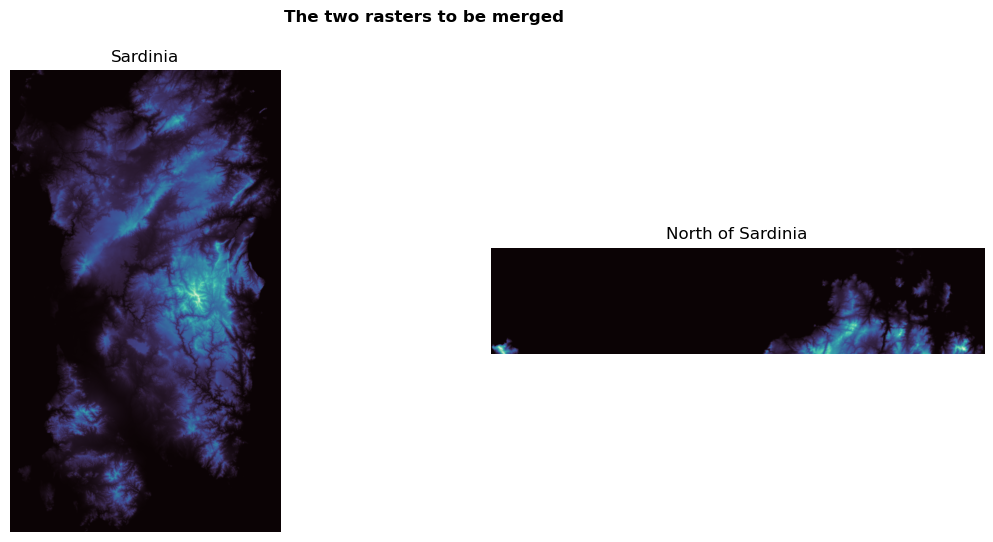

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle("The two rasters to be merged", fontweight="bold")

#sardinia
axes[0].imshow(rasters_to_mosaic[0].sel(band=1), cmap="mako", vmin=0)
axes[0].set_title("Sardinia")
axes[0].axis("off")

#north sardinia
axes[1].imshow(rasters_to_mosaic[1].sel(band=1), cmap="mako", vmin=0)
axes[1].set_title("North of Sardinia")
axes[1].axis("off")

plt.show()

We will use the [`merge_arrays()`](https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.merge.merge_arrays) from `rioxarray`:

As an argument we just have to give the list of our two `DataArrays` to be merged:

In [12]:
rxr_merged = merge_arrays(rasters_to_mosaic)

We can plot the result and see that our rasters have been correctly merged together:

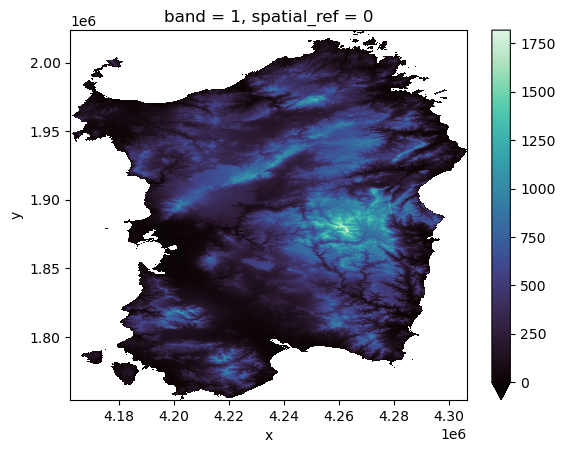

In [13]:
rxr_merged.where(rxr_merged!=rxr_merged.rio.nodata).plot(cmap="mako", vmin=0)

### • *geoutils*

With `geoutils`, we can simply use the [`merge_rasters()`](https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.raster.merge_rasters.html) function:

We start by creating the mosaic:

In [14]:
rasters_to_mosaic = [gu.Raster(r) for r in rasters]

Here are the two `geoutils.Raster` objects we want to merge:

In [15]:
rasters_to_mosaic[0]

Raster(
  data=not_loaded; shape on disk (1, 4918, 2881); will load (4918, 2881)
  transform=| 50.00, 0.00, 4162400.00|
            | 0.00,-50.00, 2000000.00|
            | 0.00, 0.00, 1.00|
  crs=EPSG:3035
  nodata=-3.4028234663852886e+38)

In [16]:
rasters_to_mosaic[1]

Raster(
  data=not_loaded; shape on disk (1, 950, 4389); will load (950, 4389)
  transform=| 25.00, 0.00, 4175200.00|
            | 0.00,-25.00, 2023750.00|
            | 0.00, 0.00, 1.00|
  crs=EPSG:3035
  nodata=-3.4028234663852886e+38)

Unlike `rasterio`, the rasters to be merged can have a different transform or CRS, and a reference raster can be passed as an argument to be reprojected considering its parameters.

One thing to mention is that all rasters data will be loaded once in memory to be used for reprojection, and will be then deleted for memory usage.

Now we can call the `merge_rasters` function, and pass the list containing our rasters as an argument:

In [17]:
gu_merged = merge_rasters(rasters_to_mosaic)

And finally we can plot our merged raster:

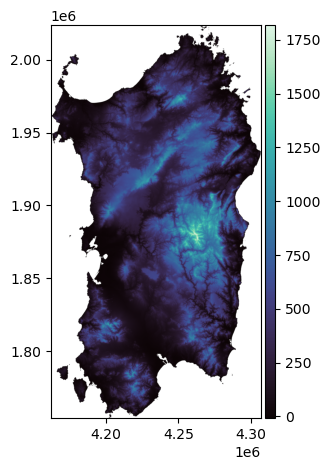

In [18]:
gu_merged.plot(cmap="mako")

### • *xarray-spatial*

`xarray-spatial` also supports Merge feature through its [`.merge()`](https://xarray-spatial.readthedocs.io/en/stable/reference/_autosummary/xrspatial.reproject.merge.html) function.

We can recreate the same mosaic object created earlier :

In [29]:
rasters_to_mosaic = [rxr.open_rasterio(r) for r in rasters]

In [33]:
rasters_to_mosaic[0]

<xarray.DataArray (band: 1, y: 4918, x: 2881)> Size: 57MB
[14168758 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 23kB 4.162e+06 4.162e+06 ... 4.306e+06 4.306e+06
  * y            (y) float64 39kB 2e+06 2e+06 2e+06 ... 1.754e+06 1.754e+06
    spatial_ref  int64 8B 0
Attributes:
    DataType:                  Generic
    AREA_OR_POINT:             Area
    RepresentationType:        ATHEMATIC
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        1578.8498535156
    STATISTICS_MEAN:           345.44952592539
    STATISTICS_MINIMUM:        -4.1803932189941
    STATISTICS_STDDEV:         298.9554336099
    STATISTICS_VALID_PERCENT:  64.37
    _FillValue:                -3.4028235e+38
    scale_factor:              1.0
    add_offset:                0.0

In [31]:
rasters_to_mosaic[1]

<xarray.DataArray (band: 1, y: 950, x: 4389)> Size: 17MB
[4169550 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 35kB 4.175e+06 4.175e+06 ... 4.285e+06 4.285e+06
  * y            (y) float64 8kB 2.024e+06 2.024e+06 2.024e+06 ... 2e+06 2e+06
    spatial_ref  int64 8B 0
Attributes:
    BandName:            Band_1
    RepresentationType:  ATHEMATIC
    AREA_OR_POINT:       Area
    _FillValue:          -3.4028235e+38
    scale_factor:        1.0
    add_offset:          0.0

We will then keep the first band of each raster of the mosaic, as the `merge` function only accepts 2D `DataArrays` :

In [34]:
rasters_mosaic_2d = [r.isel(band=0) for r in rasters_to_mosaic]

We then use the `merge` function by passing our mosaic as an input :

In [35]:
xrs_merged = xrs_merge(rasters_mosaic_2d)

Looking at the results, the two rasters have been correctly joined into a single mosaic :

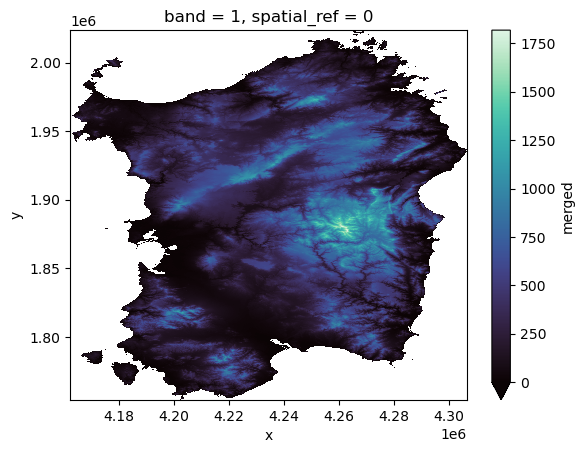

In [37]:
xrs_merged.where(xrs_merged!=xrs_merged.rio.nodata).plot(cmap="mako", vmin=0)